In [15]:
#Basic Libraries
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

#Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [16]:
#List of stock CSV files used in the project
csv_files = [
    'AMZN_100_days_30_minute_candles.csv',
    'GOOG_100_days_30_minute_candles.csv',
    'JPM_100_days_30_minute_candles.csv',
    'MSFT_100_days_30_minute_candles.csv',
    'TSLA_100_days_30_minute_candles.csv',
    'UNH_100_days_30_minute_candles.csv',
    'XOM_100_days_30_minute_candles.csv',
    'GM_100_days_30_minute_candles.csv',
    'BA_100_days_30_minute_candles.csv'
]

In [17]:
#Trading day settings

#Starts a 9:30 A.M.
start_time_astype_int = 9.5 

#Finishes at 4:00 P.M.
end_time_astype_int = 16

minutes_per_stick = 30
frequency_unit = minutes_per_stick / 60

expected_number_sticks_per_day = int((end_time_astype_int - start_time_astype_int) / frequency_unit)
expected_number_sticks_per_day += 1

print("Expected number of 30 minutes candles per day", expected_number_sticks_per_day)

Expected number of 30 minutes candles per day 14


In [24]:
def process_symbol_data(df_original):
    """
    This function:
        1. Converts timestamp into datetime.
        2. Extracts data and time features.
        3. Keeps only regular tradaing days.
        4. Removes incomlete tradins days.
        5. Returns the cleaned dataframe and its unique trading dates.
    """
    df = df_original.copy(deep=True)

    #Convers timestamps to datetime
    df['utc_datetime'] = pd.to_datetime(df.timestamp,   errors='coerce')

    #Extracts time-related columns
    df['date'] = df.utc_datetime.dt.date
    df['day'] = df.utc_datetime.dt.day
    df['time'] = df.utc_datetime.dt.time
    df['day_of_week'] = df.utc_datetime.dt.dayofweek
    df['hour'] = df.utc_datetime.dt.hour
    df['minute'] = df.utc_datetime.dt.minute

    #Remove original timestamp columns after extracting useful information
    df.drop(columns=['utc_datetime','timestamp'], inplace=True)

    #Sorts by date and time
    df.sort_values(by =['date', 'time'], ascending=[False, True],inplace=True)

    #Keeps only regular market hours
    start_time = dt.time(9,30,0)
    stop_time = dt.time(16,0,0)

    #drop time slots we dont care about
    df = df[df.time >=start_time]
    df = df[df.time <=stop_time]

    #Counts number of sticks in each trading day
    df['number_sticks_per_day'] = df.groupby('date')['date'].transform('count')

    #Keeps pnly days with enough candlesticks
    df =df[df['number_sticks_per_day'] >= expected_number_sticks_per_day]
    
    #Removes missing values
    df.dropna(inplace=True)

    #Saves uniques dates
    series_unique_dates = df.date.unique()

    #Removes helper column
    df.drop(columns=['number_sticks_per_day'],inplace=True)
    
    return df, series_unique_dates

In [30]:
def load_all_symbol_data():
    """
    Loads and processes all stocks CSV files.

    Returns a dictionary where each key is a stock symbol 
    and each value contains:
        1. The cleaned dataframe.
        2. The list of unique trading dates.
    """
    dataframes = {}
    
    for file_path in csv_files:
        df_original = pd.read_csv(file_path)
        symbol = df_original['symbol'].iloc[0]  # stock symbol
        
        df, series_unique_dates = process_symbol_data(df_original)
        dataframes[symbol] = (df, series_unique_dates)

        print(symbol, "loaded with shape", df.shape) 
    
    return dataframes
symbol_data = load_all_symbol_data()

AMZN loaded with shape (966, 14)
GOOG loaded with shape (966, 14)
JPM loaded with shape (476, 14)
MSFT loaded with shape (966, 14)
TSLA loaded with shape (966, 14)
UNH loaded with shape (784, 14)
XOM loaded with shape (742, 14)
GM loaded with shape (42, 14)
BA loaded with shape (238, 14)


In [46]:
def trend_viable(min_length,min_strength,x1,x2,y1,y2):
    """
    Checks if a price movement is strong enough and
    long enough to be considerd a trend.
    """
    #Check if the trend duration is lasted long enough
    if (x2-x1) >= min_length:
        #Is trend strong enoug?
        slope =  (y2-y1)/(x2-x1)
        #Abs of slope is magnitude.
        if abs(slope) >= min_strength:
            #trend is viable
            return True
            
    return False

In [47]:
def consecutive_trend_search(series):
    """
    Labels each candle as part of an uptrend or downtrend.
    up_trends: array where 1 means the candle belongs to an uptrend.
    down_trends: array where 1 menas the candle belongs to a downtrend.
    """
    up_trends = np.zeros(len(series['close']), dtype=int)
    down_trends = np.zeros(len(series['close']), dtype=int)

    prices = np.array(series['close'])

    n = 0
    direction = 0
    trend_started = False

    #Minimum trend requirements
    min_up_length = 3
    min_up_strength = 0.001

    min_down_length = 3
    min_down_strength = 0.001 * np.mean(prices)
    
    for i in range(len(prices) - 1):
        #Price moves up
        if prices[i] < prices[i+1]:
            if trend_started and direction != 1:
                if trend_viable(min_up_length, min_up_strength, n, i, prices[n], prices[i]):
                    up_trends[n:i] = 1
                trend_started = False

            if not trend_started:
                n = i
                trend_started = True
                direction = 1
            
        #Price moves down
        elif prices[i] > prices[i+1]:
            if trend_started and direction != -1:
                if trend_viable(min_down_length, min_down_strength, n, i, prices[n], prices[i]):
                    down_trends[n:i] = 1
                trend_started = False

            if not trend_started:
                n = i
                trend_started = True
                direction = -1

        #Price stays the same
        else:
            if trend_started and direction == 1:
                if trend_viable(min_up_length, min_up_strength, n, i, prices[n], prices[i]):
                    up_trends[n:i] = 1


    
            if trend_started and direction == -1:
                if trend_viable(min_down_length, min_down_strength, n, i, prices[n], prices[i]):
                    down_trends[n:i] = 1
            
            trend_started = False
        
    #Checks the last trend at the end of the day
    last_i = len(prices) - 1

    if trend_started and direction == 1:
        if trend_viable(min_up_length, min_up_strength, n, i, prices[n], prices[i]):
            up_trends[n:i] = 1
    
    if trend_started and direction == -1:
        if trend_viable(min_down_length, min_down_strength, n, i, prices[n], prices[i]):
            down_trends[n:i] = 1

    return up_trends, down_trends
    
    

In [48]:
def fill_holes(day, expected_size):
    """
    Makes sure each trading day has the expected number of candles. 
    Missing values are filled using linear interpolation.
    """

    if len(day) ==  expected_size:
        return day

    day = day.copy(deep=True)

    #Gets the dat as a string
    str_date = day.iloc[0]['date'].strftime('%Y-%m-%d')

    #Creates expected start and stop times
    start_time = dt.datetie.strptime(str_date + '09:30', '%Y-%m-%d %H:%M')
    stop_time = dt.datetime.strptime(str_date + '16:00', '%Y-%m-%d %H:%M')

    #Create expected timestamps
    timestamps = np.linspace(start_time.timestamp(), stop_time.timestamp(), num=expected_size)
    ts_array = pd.to_datetime(timestamp(), units='s')

    expected_time_series = pd.DataFrame({
        'date': ts_array.date,
        'time': ts_array.time
    })

    #Merges real dadt data with expected time slots
    merged_df = pd.merge(
        day,
        expected_time_series,
        how='outer',
        letf_on=['date', 'time'],
        right_on=['date', 'time'],
    )

    #Sorts by time
    merged_df.sort_values(by='time', inplace=True)

    #Fills symbols if missing
    if 'symbol' in merged_df.columns:
        merged_df['symbol'] = merged_df['symbol'].ffill().bfill()


    #Fills date and time related features
    merged_df['day'] = merged_df['day'].ffill().bfill()
    merged_df['day_of_week'] = merged_df['day_of_week'].ffill().bfill()
    merged_df['hour'] = pd.to_datetime(merged_df['time'].astype(str)).dt.hour
    merged_df['minute'] = pd.to_datetime(merged_df['time'].astype(str)).dt.minute

    #Interpolates numeric market columns
    numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']
    
    for col in numeric_cols:
        merged_df[col] = merged_df[col].interpolate(method="linear")
        merged_df[col] = merged_df[col].ffill().bfill()
        
        return merged_df

In [51]:
#Features used by the model
feature_cols = [
    'open', 
    'high', 
    'low', 
    'close', 
    'volume', 
    'trade_count', 
    'vwap',
    'day_of_week',
    'hour',
    'minute'
]

#Trend label columns
trend_cols = ['up_trend', 'down_trend', 'no_trend']

#This list will store all rows for the logistic regression datset
log_reg_rows = []

for symbol, (df, series_unique_dates) in symbol_data.items():
    
    for day_i in series_unique_dates:

        #Gets one trading day for one stock
        day = df[df['date'] == day_i].copy(deep=True)
        day.sort_values(by='time', ascending=True, inplace=True)

        #Makes sure the day has the expected number of candles
        day = fill_holes(day, expected_number_sticks_per_day)

        #Creates trend Labels
        up, down = consecutive_trend_search(day)

        day['up_trend'] = up
        day['down_trend'] = down
        day['no_trend'] = np.logical_not(day['up_trend'] | day['down_trend']).astype(int)

        #add stock symbol and date for reference
        day['symbol_name'] = symbol
        day['sample_date'] = day_i

        #Keeps only the columns needed
        keep_cols = ['symbol_name', 'sample_date'] + feature_cols + trend_cols
        
        log_reg_rows.append(day[keep_cols])


#Combines all rows into one dataframe
log_reg_df = pd.concat(log_reg_rows, ignore_index=True)

print("Logistic regression dataset shape:", log_reg_df.shape)
log_reg_df.head()
        

Logistic regression dataset shape: (6146, 15)


,symbol_name,sample_date,open,high,low,close,volume,trade_count,vwap,day_of_week,hour,minute,up_trend,down_trend,no_trend
0,AMZN,2026-05-08,272.150,272.2924,271.80,271.860,11953.0,360.0,271.962901,4,9,30,0,0,1
1,AMZN,2026-05-08,271.900,271.9000,271.70,271.839,3098.0,108.0,271.843970,4,10,0,0,0,1
2,AMZN,2026-05-08,271.880,271.9900,271.41,271.750,13151.0,458.0,271.661844,4,10,30,0,0,1
3,AMZN,2026-05-08,271.625,272.4000,271.58,272.290,51886.0,1130.0,271.878440,4,11,0,0,0,1
4,AMZN,2026-05-08,272.220,272.2500,271.88,271.880,26360.0,662.0,272.067070,4,11,30,0,0,1


In [53]:
#Converts the three columns into one target lsbel column
log_reg_df['target'] = log_reg_df[trend_cols].idxmax(axis=1)

print("Class distribution:")
print(log_reg_df['target'].value_counts())

print("\nClass distribution as percentages:")
print(log_reg_df["target"].value_counts(normalize=True) *100)

Class distribution:
target
no_trend      4227
up_trend      1065
down_trend     854
Name: count, dtype: int64

Class distribution as percentages:
target
no_trend      68.776440
up_trend      17.328344
down_trend    13.895216
Name: proportion, dtype: float64


In [66]:
#Define X and Y
X = log_reg_df[feature_cols].copy()
y = log_reg_df['target'].copy()

print("X shape", X.shape)
print("y shape", y.shape)

X shape (6146, 10)
y shape (6146,)


In [68]:
#Splits the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape", X_train.shape)
print("Testing set shape", X_test.shape)

Training set shape (4916, 10)
Testing set shape (1230, 10)


In [81]:
#Standardizes the input features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


In [105]:
#Trains regularized logistic regression

log_reg_model = LogisticRegression(
    penalty='l2', #L2 regularization
    C=1.0, #Smaller C means stronger regularizaton
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight= 'balanced'
)

log_reg_model.fit(X_train_scaled, y_train)

print("Regularized logistic regression model trained successfully.")


Regularized logistic regression model trained successfully.


In [106]:
#Makes predictions on the test set
y_pred = log_reg_model.predict(X_test_scaled)

#Calculates accuracy
accuracy = accuracy_score(y_test, y_pred)

print("The model accuracy is:", accuracy)

print("\nClassification Report:",)
print(classification_report(y_test, y_pred, zero_division=0))

The model accuracy is: 0.44715447154471544

Classification Report:
              precision    recall  f1-score   support

  down_trend       0.22      0.25      0.23       171
    no_trend       0.74      0.49      0.59       846
    up_trend       0.19      0.42      0.26       213

    accuracy                           0.45      1230
   macro avg       0.38      0.39      0.36      1230
weighted avg       0.57      0.45      0.49      1230



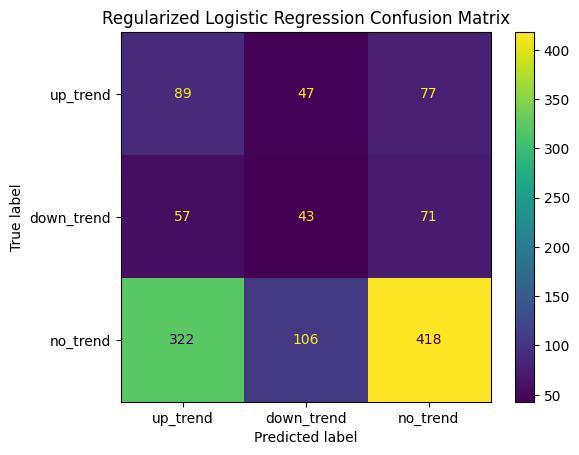

In [107]:
#Plots the confusion matrix
class_labels = ['up_trend', 'down_trend', 'no_trend']
cm = confusion_matrix(y_test, y_pred, labels=class_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

disp.plot(values_format='d')
plt.title("Regularized Logistic Regression Confusion Matrix")
plt.show()

In [108]:
#Views model coefficientsfor interpretability
coef_df = pd.DataFrame(
    log_reg_model.coef_,
    columns=feature_cols,
    index=log_reg_model.classes_
)

coef_df

,open,high,low,close,volume,trade_count,vwap,day_of_week,hour,minute
down_trend,-2.952568,0.844564,-0.946080,2.751437,0.171086,-0.127419,0.308433,0.048441,-0.106282,-0.051552
no_trend,-0.045919,-1.354097,1.542527,-0.223577,-0.027242,-0.034264,0.099728,-0.025931,0.289762,0.094949
up_trend,2.998487,0.509533,-0.596447,-2.527859,-0.143844,0.161682,-0.408161,-0.022510,-0.183479,-0.043397


In [109]:
#Compares actual vs predicted labels

results_df = pd.DataFrame({
    'actual':y_test.values,
    'predicted':y_pred
})

results_df.head(25)

,actual,predicted
0,no_trend,up_trend
1,no_trend,up_trend
2,no_trend,no_trend
3,no_trend,no_trend
4,no_trend,up_trend
5,no_trend,no_trend
6,no_trend,up_trend
7,down_trend,no_trend
8,no_trend,up_trend
9,no_trend,no_trend


In [110]:
#Saves predictions and model coefficients for the report
results_df.to_csv('jimenez_logistic_regression_coefficients.csv')

print("Results saved succesfully")

Results saved succesfully
